# MetalloDock 虚拟筛选教程

本 notebook 只保留 **自回归位移生成** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `RMSD < 2A`

In [1]:
import sys
import warnings
from pathlib import Path
from collections import deque
from scipy.spatial import distance_matrix

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from rdkit import RDLogger
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, compute_rmsd,
    describe_model_parameters, history_frame, load_complex,
    metric_frame, parse_pdb_ids, plot_loss_curves,
)

## 1. 超参数设置

| 参数 | 说明 |
|------|------|
| `POCKET_CUTOFF` | 截取口袋原子的距离阈值 |
| `COORD_NOISE_STD` | 训练时对配体坐标添加的高斯噪声标准差（增强鲁棒性） |

In [2]:
POCKET_CUTOFF = 8.0
COORD_NOISE_STD = 0.3
HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

display(pd.DataFrame({
    '超参数': ['ATOM_FEAT_DIM', 'HIDDEN_DIM', 'N_EPOCHS', 'LR',
              'POCKET_CUTOFF', 'COORD_NOISE_STD', 'DEVICE'],
    '值': [ATOM_FEAT_DIM, HIDDEN_DIM, N_EPOCHS, LR,
           f'{POCKET_CUTOFF} A', COORD_NOISE_STD, str(DEVICE)],
    '说明': ['简化原子特征维度', '隐层维度', '训练轮数', '学习率',
             '截取口袋原子的距离阈值',
             '训练时对配体坐标添加的噪声标准差', '计算设备']
}))

,超参数,值,说明
0,ATOM_FEAT_DIM,10,简化原子特征维度
1,HIDDEN_DIM,128,隐层维度
2,N_EPOCHS,200,训练轮数
3,LR,0.001,学习率
4,POCKET_CUTOFF,8.0 A,截取口袋原子的距离阈值
5,COORD_NOISE_STD,0.3,训练时对配体坐标添加的噪声标准差
6,DEVICE,cuda,计算设备


## 2. 数据加载与特征提取

MetalloDock 的数据处理流程：

1. 加载蛋白口袋与配体的 3D 结构
2. 截取 POCKET_CUTOFF 内的口袋原子
3. **BFS 排序**：确定原子的自回归生成顺序（模型特有，保留在 notebook 中）
4. **提取键长**：作为生成时的距离约束

In [3]:
def bfs_atom_order(mol, start_idx=0):
    """广度优先搜索确定原子生成顺序（参考 MetalloDock BFS_search）。

    返回:
      atom_order  : list[int] -- 原子生成顺序
      parent_list : list[int] -- 每个原子的父原子索引（第一个原子为 -1）
    """
    num_atoms = mol.GetNumAtoms()
    visited = [False] * num_atoms
    atom_order = [start_idx]
    parent_list = [-1]
    visited[start_idx] = True
    queue = deque([start_idx])
    while queue:
        current = queue.popleft()
        for neighbor in mol.GetAtomWithIdx(current).GetNeighbors():
            nb_idx = neighbor.GetIdx()
            if not visited[nb_idx]:
                visited[nb_idx] = True
                queue.append(nb_idx)
                atom_order.append(nb_idx)
                parent_list.append(current)
    return atom_order, parent_list


def get_bond_lengths(mol, conf):
    """提取分子中所有键的键长，返回 {(i,j): length} 字典。"""
    bond_lengths = {}
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        pi = np.array(conf.GetAtomPosition(i))
        pj = np.array(conf.GetAtomPosition(j))
        length = float(np.linalg.norm(pi - pj))
        bond_lengths[(i, j)] = length
        bond_lengths[(j, i)] = length
    return bond_lengths


def build_metallodock_data(pdbid):
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_mol, lig_mol = cplx["prot_mol"], cplx["lig_mol"]
    prot_coords, lig_coords = cplx["prot_coords"], cplx["lig_coords"]

    prot_feats = np.array([atom_features(a) for a in prot_mol.GetAtoms()], dtype=np.float32)
    lig_feats = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)

    if lig_mol.GetNumAtoms() < 2:
        return None

    lig_center = lig_coords.mean(axis=0)
    prot_dists = np.linalg.norm(prot_coords - lig_center, axis=1)
    pocket_mask = prot_dists < POCKET_CUTOFF
    if pocket_mask.sum() < 3:
        top_k = min(20, len(prot_coords))
        pocket_idx = np.argsort(prot_dists)[:top_k]
        prot_coords = prot_coords[pocket_idx]
        prot_feats = prot_feats[pocket_idx]
    else:
        prot_coords = prot_coords[pocket_mask]
        prot_feats = prot_feats[pocket_mask]

    dists_to_pocket = np.linalg.norm(lig_coords - prot_coords.mean(axis=0), axis=1)
    start_idx = int(np.argmin(dists_to_pocket))
    atom_order, parent_list = bfs_atom_order(lig_mol, start_idx=start_idx)

    lig_conf = lig_mol.GetConformer()
    bond_lengths = get_bond_lengths(lig_mol, lig_conf)

    return (prot_feats, lig_feats, prot_coords, lig_coords,
            atom_order, parent_list, bond_lengths)


pdb_ids = parse_pdb_ids(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(pdb_ids)} 个复合物")

all_data = []
for pdbid in sorted(pdb_ids):
    result = build_metallodock_data(pdbid)
    if result is not None:
        all_data.append(result)

print(f"成功加载 {len(all_data)} 个复合物")

sample = all_data[0]
display(pd.DataFrame({
    '属性': ['蛋白口袋原子数', '配体原子数', '蛋白特征维度', '配体特征维度',
             'BFS 序列长度', '键数量'],
    '值': [sample[0].shape[0], sample[1].shape[0],
           sample[0].shape[1], sample[1].shape[1],
           len(sample[4]), len(sample[6]) // 2]
}))

从 CoreSet.dat 读取到 20 个复合物
成功加载 20 个复合物


,属性,值
0,蛋白口袋原子数,89
1,配体原子数,36
2,蛋白特征维度,10
3,配体特征维度,10
4,BFS 序列长度,36
5,键数量,39


## 3. 数据集与数据加载器

由于每个蛋白-配体复合物的原子数不同（变长结构），使用 `BATCH_SIZE=1` 逐样本处理。

`__getitem__` 将 BFS 序列中每对 `(child, parent)` 的键长提取为数组 `bond_len_seq`，供自回归生成时使用。

In [4]:
class MetalloDockDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        (prot_f, lig_f, prot_c, lig_c,
         atom_order, parent_list, bond_lengths) = self.data[idx]

        n_lig = len(atom_order)
        bond_len_seq = np.zeros(n_lig, dtype=np.float32)
        for i in range(1, n_lig):
            child = atom_order[i]
            parent = parent_list[i]
            bond_len_seq[i] = bond_lengths.get((child, parent), 1.5)

        return (torch.FloatTensor(prot_f),
                torch.FloatTensor(lig_f),
                torch.FloatTensor(prot_c),
                torch.FloatTensor(lig_c),
                torch.LongTensor(atom_order),
                torch.LongTensor(parent_list),
                torch.FloatTensor(bond_len_seq))


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(MetalloDockDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(MetalloDockDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '总计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}',
             f'{len(test_data)/len(all_data):.0%}', '100%']
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,总计,20,100%


## 4. 模型架构

本节只保留 **MetalloDock 的技术路线**：按照原子生成顺序，自回归地预测下一个原子的位移。

```
已放置原子的坐标 + 蛋白口袋 + 当前父原子
  -> 蛋白/配体嵌入 -> 父原子-口袋上下文聚合
  -> 输出 3D 位移向量
  -> 新原子坐标 = 父原子坐标 + 位移
```

**核心创新**：按 BFS 顺序自回归生成，每一步的位移以父原子为锚点，保证了生成顺序与分子拓扑一致。

In [5]:
class ToyMetalloDock(nn.Module):
    """保留自回归位移生成路线，骨架只用 Linear + ReLU。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.prot_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.lig_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.context_head = build_mlp(hidden_dim * 2 + 1, hidden_dim, hidden_dim)
        self.displacement_head = build_mlp(hidden_dim * 2, hidden_dim, 3)

    def predict_displacement(self, prot_h, lig_h, prot_c, parent_coord, parent_idx):
        dist = torch.norm(prot_c - parent_coord.unsqueeze(0), dim=-1, keepdim=True)
        parent_h = lig_h[parent_idx].unsqueeze(0).expand(prot_h.size(0), -1)
        context = self.context_head(torch.cat([parent_h, prot_h, dist], dim=-1)).mean(dim=0)
        return self.displacement_head(torch.cat([lig_h[parent_idx], context], dim=-1))

    def forward_train(self, prot_f, lig_f, prot_c, lig_c, atom_order, parent_list, bond_len_seq):
        prot_h = self.prot_embed(prot_f)
        lig_h = self.lig_embed(lig_f)
        per_atom_losses = []
        for step in range(1, atom_order.numel()):
            child_idx = atom_order[step].item()
            parent_idx = parent_list[step].item()
            # 训练时对父原子坐标添加噪声（参考原版 MetalloDock 的坐标扰动策略）
            parent_coord = lig_c[parent_idx] + torch.randn(3, device=lig_c.device) * COORD_NOISE_STD
            target_disp = lig_c[child_idx] - parent_coord
            pred_disp = self.predict_displacement(prot_h, lig_h, prot_c, parent_coord, parent_idx)
            per_atom_losses.append(((pred_disp - target_disp) ** 2).mean())
        return torch.stack(per_atom_losses).mean() if per_atom_losses else torch.tensor(0.0, device=prot_f.device)

    def forward_inference(self, prot_f, lig_f, prot_c, atom_order, parent_list, bond_len_seq, pocket_center):
        prot_h = self.prot_embed(prot_f)
        lig_h = self.lig_embed(lig_f)
        pred_coords = torch.zeros((lig_f.size(0), 3), device=prot_f.device)
        pred_coords[atom_order[0]] = pocket_center
        for step in range(1, atom_order.numel()):
            child_idx = atom_order[step].item()
            parent_idx = parent_list[step].item()
            parent_coord = pred_coords[parent_idx]
            pred_disp = self.predict_displacement(prot_h, lig_h, prot_c, parent_coord, parent_idx)
            pred_coords[child_idx] = parent_coord + pred_disp
        return pred_coords


model = ToyMetalloDock(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,prot_embed.0.weight,"(128, 10)",1280
1,prot_embed.0.bias,"(128,)",128
2,prot_embed.2.weight,"(128, 128)",16384
3,prot_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 10)",1280
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,context_head.0.weight,"(128, 257)",32896
9,context_head.0.bias,"(128,)",128


## 5. 训练

训练采用 **Teacher Forcing** 策略：
- 训练时使用真实坐标（加少量高斯噪声）作为已放置原子的坐标
- 逐步预测每个原子的位移方向
- 损失函数 = 逐原子位移坐标 MSE 均值

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train_loss_history = []
val_loss_history = []

print(f"开始训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for prot_f, lig_f, prot_c, lig_c, atom_order, parent_list, bond_len_seq in train_loader:
        prot_f = prot_f.squeeze(0).to(DEVICE)
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_c = prot_c.squeeze(0).to(DEVICE)
        lig_c = lig_c.squeeze(0).to(DEVICE)
        atom_order = atom_order.squeeze(0).to(DEVICE)
        parent_list = parent_list.squeeze(0).to(DEVICE)
        bond_len_seq = bond_len_seq.squeeze(0).to(DEVICE)
        loss = model.forward_train(prot_f, lig_f, prot_c, lig_c, atom_order, parent_list, bond_len_seq)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for prot_f, lig_f, prot_c, lig_c, atom_order, parent_list, bond_len_seq in test_loader:
            prot_f = prot_f.squeeze(0).to(DEVICE)
            lig_f = lig_f.squeeze(0).to(DEVICE)
            prot_c = prot_c.squeeze(0).to(DEVICE)
            lig_c = lig_c.squeeze(0).to(DEVICE)
            atom_order = atom_order.squeeze(0).to(DEVICE)
            parent_list = parent_list.squeeze(0).to(DEVICE)
            bond_len_seq = bond_len_seq.squeeze(0).to(DEVICE)
            val_losses.append(model.forward_train(prot_f, lig_f, prot_c, lig_c,
                                                   atom_order, parent_list, bond_len_seq).item())

    train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
    val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

开始训练 200 轮...

Epoch   1/200 | Train Loss: 0.7583 | Val Loss: 0.8390
Epoch  20/200 | Train Loss: 0.7484 | Val Loss: 0.7663
Epoch  40/200 | Train Loss: 0.7778 | Val Loss: 0.8513
Epoch  60/200 | Train Loss: 0.7273 | Val Loss: 0.8324
Epoch  80/200 | Train Loss: 0.7047 | Val Loss: 0.8671
Epoch 100/200 | Train Loss: 0.6659 | Val Loss: 0.8151
Epoch 120/200 | Train Loss: 0.6727 | Val Loss: 0.7940
Epoch 140/200 | Train Loss: 0.6661 | Val Loss: 0.8841
Epoch 160/200 | Train Loss: 0.6401 | Val Loss: 0.8647
Epoch 180/200 | Train Loss: 0.6499 | Val Loss: 0.8710
Epoch 200/200 | Train Loss: 0.6227 | Val Loss: 1.0496


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`RMSD < 2A`。

In [7]:
print("在测试集上评估自回归位移生成...")
model.eval()
all_rmsds = []

with torch.no_grad():
    for prot_f, lig_f, prot_c, lig_c, atom_order, parent_list, bond_len_seq in test_loader:
        prot_f = prot_f.squeeze(0).to(DEVICE)
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_c = prot_c.squeeze(0).to(DEVICE)
        lig_c_np = lig_c.squeeze(0).numpy()
        atom_order = atom_order.squeeze(0).to(DEVICE)
        parent_list = parent_list.squeeze(0).to(DEVICE)
        bond_len_seq = bond_len_seq.squeeze(0).to(DEVICE)
        pocket_center = prot_c.mean(dim=0)
        pred_coords = model.forward_inference(
            prot_f, lig_f, prot_c, atom_order, parent_list, bond_len_seq, pocket_center
        )
        pred_np = pred_coords.cpu().numpy()
        all_rmsds.append(compute_rmsd(pred_np, lig_c_np))

all_rmsds = np.asarray(all_rmsds, dtype=np.float32)
success_rate = float((all_rmsds < 2.0).mean() * 100.0)
display(metric_frame([("RMSD < 2A", f"{success_rate:.1f}%")]))

在测试集上评估自回归位移生成...


,指标,值
0,RMSD < 2A,0.0%


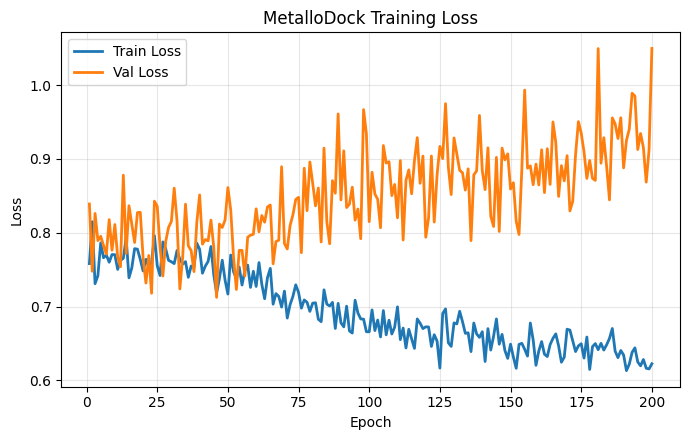

In [8]:
plot_loss_curves(train_loss_history, val_loss_history, title="MetalloDock Training Loss")

## 总结

- 技术路线：保留 MetalloDock 的自回归位移生成路线。
- 教学骨架：统一为 `nn.Linear() + nn.ReLU()` 的简单 MLP。
- 训练输出：统一展示 train / val loss history。
- 主指标：`RMSD < 2A`。